In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [19]:

CURRENT_YEAR = 2025
OUT = "output"
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv("car_data.csv")

In [20]:
print(df.head())

         Make   Model  Year Fuel_Type Transmission  Mileage     Price
0  Volkswagen  Tiguan  2022    Petrol       Manual  24532.0  20125.21
1         BMW      X3  2021    Petrol       Manual  31570.0  30899.47
2      Toyota    RAV4  2016    Petrol    Automatic  80736.0  10739.60
3  Volkswagen  Passat  2023    Petrol    Automatic   2000.0  21661.40
4         BMW    320i  2017    Diesel    Automatic  49349.0  24182.72


In [21]:
print(df.dtypes)

Make             object
Model            object
Year              int64
Fuel_Type        object
Transmission     object
Mileage         float64
Price           float64
dtype: object


In [22]:
print(df.select_dtypes('number').columns)

Index(['Year', 'Mileage', 'Price'], dtype='object')


In [23]:
print(df.select_dtypes(exclude='number').columns)

Index(['Make', 'Model', 'Fuel_Type', 'Transmission'], dtype='object')


In [24]:
print(df.describe())

              Year        Mileage         Price
count   900.000000     885.000000    885.000000
mean   2016.528889   76044.679096  13556.798768
std       4.058286   37540.440155   9050.756560
min    2010.000000    2000.000000   2641.320000
25%    2013.000000   42193.000000   6862.130000
50%    2016.000000   78277.000000  11258.740000
75%    2020.000000  106277.000000  17547.300000
max    2023.000000  161279.000000  47501.110000


In [25]:
print(df.isnull().sum())

Make             0
Model            0
Year             0
Fuel_Type        0
Transmission     0
Mileage         15
Price           15
dtype: int64


In [26]:
# (i) Cars priced above $25,000  +  their average mileage
expensive = df[df["Price"] > 25000]              # mask keeps Price>25000 rows
print("(i) Count >$25k :", len(expensive))
print("    Avg mileage :", round(expensive["Mileage"].mean(), 2))  # mean ignores NaN

(i) Count >$25k : 89
    Avg mileage : 33858.06


In [27]:
# (ii) Average price for Petrol vs Diesel
print("(ii) Avg price by fuel:")
print(df.groupby("Fuel_Type")["Price"].mean().round(2))


(ii) Avg price by fuel:
Fuel_Type
Diesel    13698.80
Petrol    13464.34
Name: Price, dtype: float64


In [28]:
# (iii) Per-make summary: average price AND maximum mileage
summary = df.groupby("Make").agg(
    avg_price=("Price", "mean"),                 # name -> (column, function)
    max_mileage=("Mileage", "max")
).round(2)
print("(iii) Per-make summary:")
print(summary)

(iii) Per-make summary:
               avg_price  max_mileage
Make                                 
Audi            21469.01     152999.0
BMW             23870.67     161279.0
Ford             9031.42     157377.0
Honda           10840.87     142862.0
Hyundai          7627.77     142952.0
Mercedes-Benz   22786.29     147471.0
Nissan           8841.24     149979.0
Toyota          12109.50     147984.0
Volkswagen      11173.91     146747.0


In [29]:

# ---- 4a(iv)  add a Mileage Category column (Low / Moderate / High) -------------
# pd.cut slices a numeric column into labelled bins.
# Bins:  (0, 30000] -> Low | (30000, 100000] -> Moderate | (100000, inf) -> High
df["Mileage Category"] = pd.cut(
    df["Mileage"],
    bins=[0, 30000, 100000, np.inf],
    labels=["Low", "Moderate", "High"]
)
print("\n[iv] Mileage Category counts:")
print(df["Mileage Category"].value_counts().to_string())
print("    sample:")
print(df[["Make", "Mileage", "Mileage Category"]].head(5).to_string(index=False))



[iv] Mileage Category counts:
Moderate    496
High        271
Low         118
    sample:
      Make  Mileage Mileage Category
Volkswagen  24532.0              Low
       BMW  31570.0         Moderate
    Toyota  80736.0         Moderate
Volkswagen   2000.0              Low
       BMW  49349.0         Moderate


In [30]:
# ---- 4a(v)  highest-priced car for every make ---------------------------------
# idx of the max Price within each make, then fetch those whole rows
idx = df.groupby("Make")["Price"].idxmax()     # row label of the dearest car per make
top_per_make = df.loc[idx, ["Make", "Model", "Year", "Price"]].sort_values("Price",
                                                                ascending=False)
print("\n[v] Highest-priced car per make:")
print(top_per_make.to_string(index=False))


print("\n" + "=" * 70)
print("QUESTION 4b  -  CAR DATASET VISUALISATION")
print("=" * 70)


[v] Highest-priced car per make:
         Make   Model  Year    Price
Mercedes-Benz     GLA  2023 47501.11
          BMW    520d  2023 46318.50
         Audi      A6  2022 40768.77
       Toyota   Camry  2023 26711.82
        Honda    CR-V  2023 24389.19
   Volkswagen    Golf  2023 24310.55
         Ford  Escape  2023 19944.79
       Nissan Qashqai  2023 19081.28
      Hyundai Elantra  2023 18181.10

QUESTION 4b  -  CAR DATASET VISUALISATION


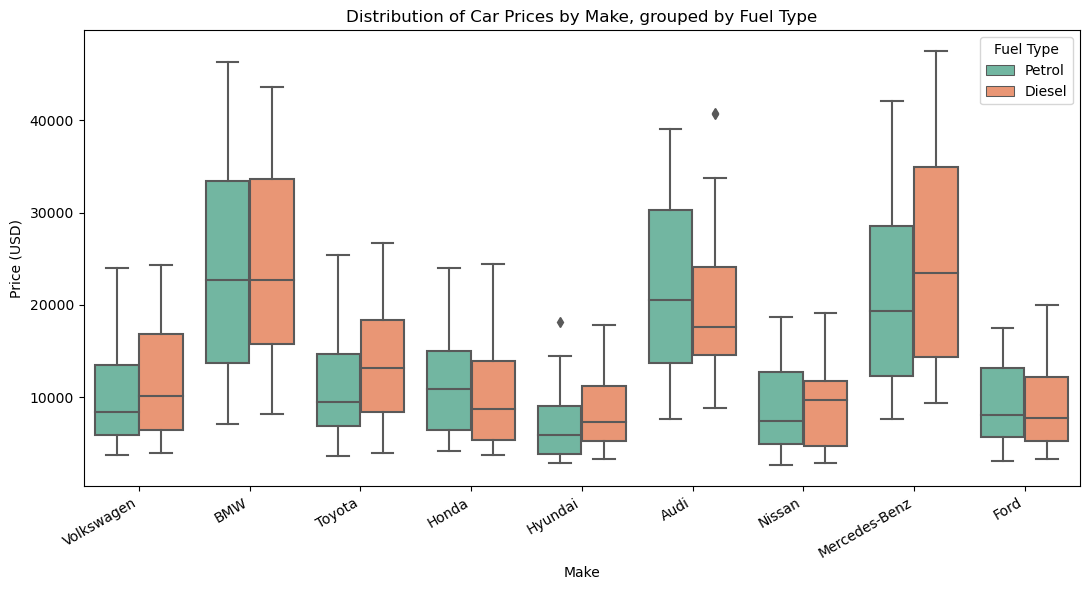

In [38]:
# ---- 4b(i)  boxplot of Price per Make, grouped by Fuel_Type --------------------
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="Make", y="Price", hue="Fuel_Type", palette="Set2")

plt.title("Distribution of Car Prices by Make, grouped by Fuel Type")
plt.xlabel("Make")
plt.ylabel("Price (USD)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Fuel Type")

plt.tight_layout()
plt.show()

In [33]:
# ---- 4b(ii)  average price per make, ignoring rows missing Price OR Mileage ----
clean = df.dropna(subset=["Price", "Mileage"])     # drop only where these are NaN
avg_price_clean = clean.groupby("Make")["Price"].mean().round(2)
print("\n[ii] Average price by make (rows with missing Price/Mileage removed):")
print("     rows before:", len(df), "| after:", len(clean))
print(avg_price_clean.to_string())


[ii] Average price by make (rows with missing Price/Mileage removed):
     rows before: 900 | after: 871
Make
Audi             21657.54
BMW              23729.56
Ford              8973.41
Honda            10881.78
Hyundai           7627.77
Mercedes-Benz    22710.62
Nissan            8841.24
Toyota           12092.10
Volkswagen       10973.81



[iii] Most common fuel type per brand:
Make
Audi             Petrol
BMW              Petrol
Ford             Diesel
Honda            Petrol
Hyundai          Petrol
Mercedes-Benz    Petrol
Nissan           Petrol
Toyota           Petrol
Volkswagen       Petrol


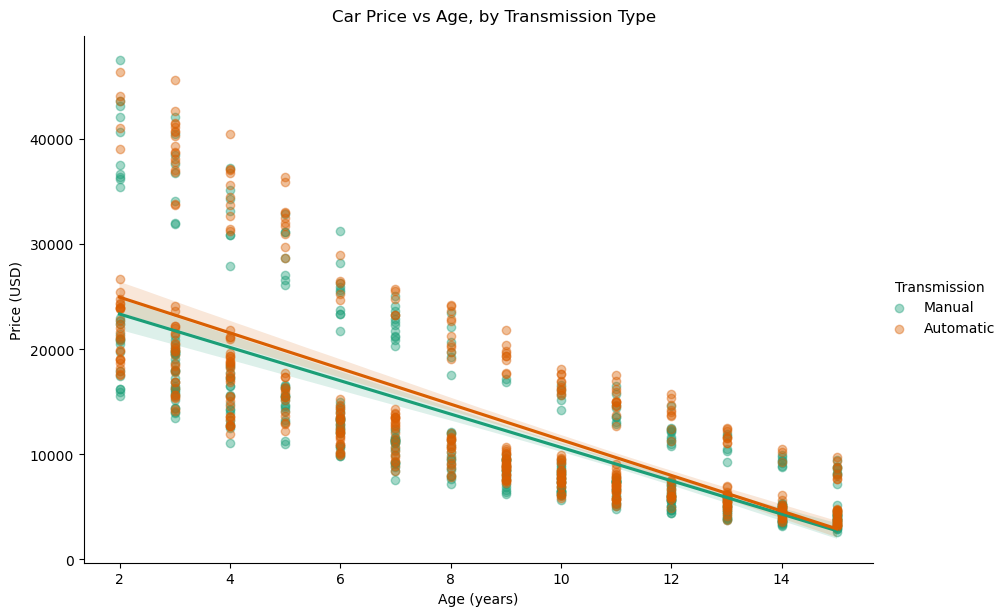


[iv] Average price by transmission:
Transmission
Automatic    14291.19
Manual       12736.32
Price-vs-Age correlation: -0.74


In [44]:
# most common fuel type per brand (the mode of Fuel_Type inside each make)
df["Age"] = 2025 - df["Year"]
most_fuel = df.groupby("Make")["Fuel_Type"].agg(lambda s: s.mode()[0])
print("\n[iii] Most common fuel type per brand:")
print(most_fuel.to_string())

# Create Age column
df["Age"] = 2025 - df["Year"]

# 4b(iv)
g = sns.lmplot(
    data=df,
    x="Age",
    y="Price",
    hue="Transmission",
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.4},
    palette="Dark2"
)

g.fig.suptitle("Car Price vs Age, by Transmission Type", y=1.02)
g.set_axis_labels("Age (years)", "Price (USD)")

plt.show()      # use this in Jupyter

# numbers backing the inference
print("\n[iv] Average price by transmission:")
print(df.groupby("Transmission")["Price"].mean().round(2).to_string())

print("Price-vs-Age correlation:",
      round(df["Age"].corr(df["Price"]), 3))

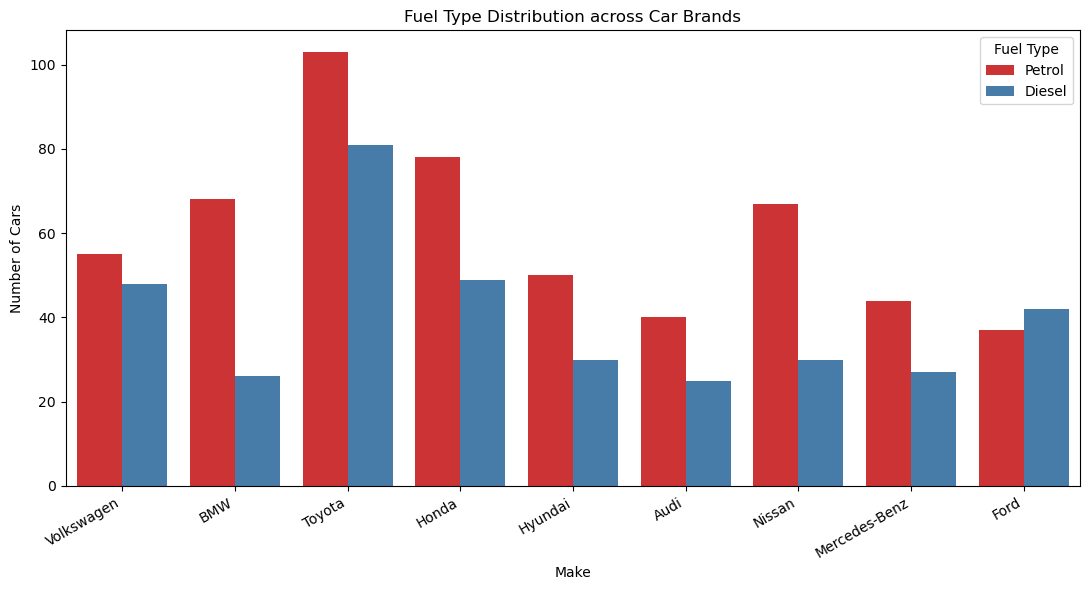

In [37]:
# ---- 4b(iii)  fuel-type distribution across brands + most common per brand -----
plt.figure(figsize=(11, 6))
sns.countplot(data=df, x="Make", hue="Fuel_Type", palette="Set1")

plt.title("Fuel Type Distribution across Car Brands")
plt.xlabel("Make")
plt.ylabel("Number of Cars")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Fuel Type")

plt.tight_layout()
plt.savefig("4b_iii_fuel.png", dpi=90)
plt.show()

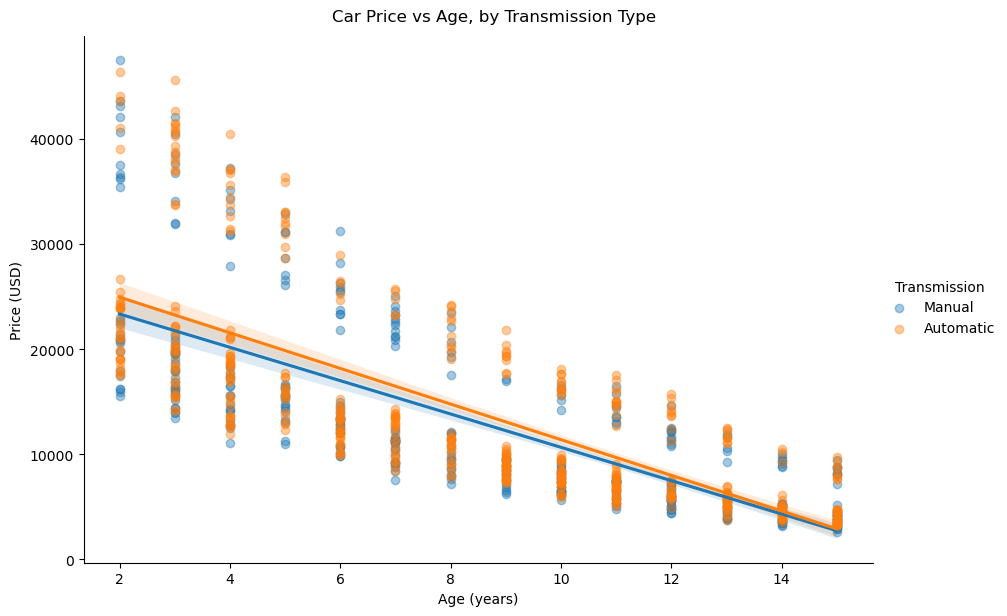

Transmission
Automatic    14291.19
Manual       12736.32
Name: Price, dtype: float64
Correlation: -0.74


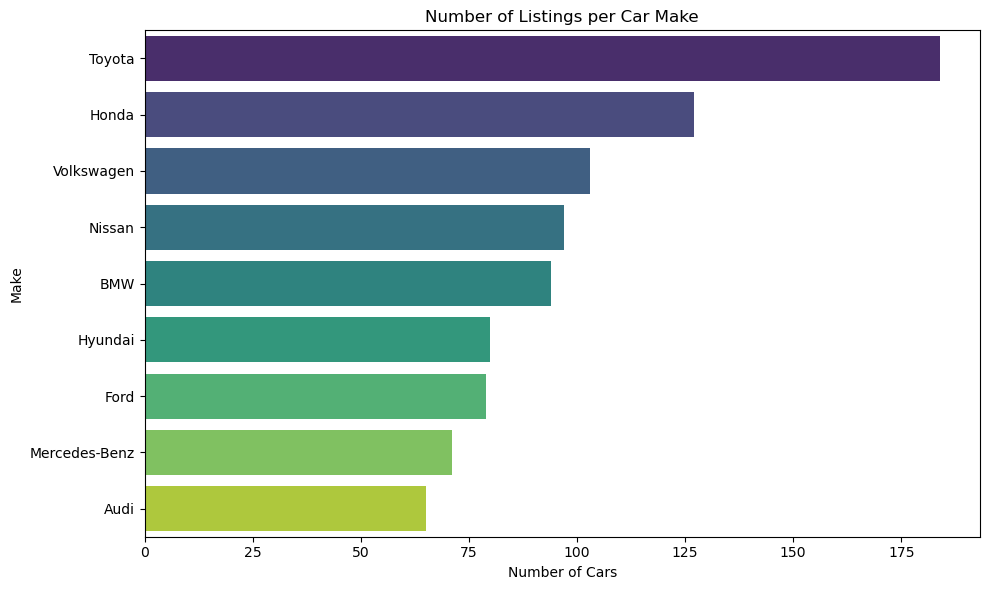

In [46]:
make_counts = df["Make"].value_counts()

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y="Make",
    order=make_counts.index,
    palette="viridis"
)

plt.title("Number of Listings per Car Make")
plt.xlabel("Number of Cars")
plt.ylabel("Make")
plt.tight_layout()
plt.show()